# Lección 1. Regresión Lineal Simple

In [1]:
from IPython.display import IFrame
IFrame('https://view.genially.com/69aeaa952756edfe293e47d5', width=900, height=500)

# Bibliotecas utilizadas

+ Numpy: Calcular manualmente la recta de regresión
+ Matplotlib: representar nube de puntos y recta de regresión

In [1]:
# Importamos las bibliotecas numpy y matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Datos

En esta ocasión, tenemos datos estadísticos de 12 estudiantes que corresponden a sus notas de físicas y matemáticas



In [2]:
import numpy as np

# Definimos las listas originales
x_list = [2,3,4,4,5,6,6,7,7,8,10,10] # Notas matemáticas
y_list = [1,3,2,4,4,4,6,4,6,7,9,10] # Notas de física

# Las convertimos a arrays de numpy
x = np.array(x_list)
y = np.array(y_list)

# Verificamos el tipo
print(f"Notas Matemáticas: {x}")
print(f"Notas Física: {y}")

Notas Matemáticas: [ 2  3  4  4  5  6  6  7  7  8 10 10]
Notas Física: [ 1  3  2  4  4  4  6  4  6  7  9 10]


# Nube de puntos

Una vez disponemos de los datos, dibujamos la nube de puntos. Esto lo hacemos mediante la función "scatter" de la biblioteca matplotlib. Debemos pasarle los datos por parámetro. Podemos nombrar los ejes con las funciones xlabel e ylabel.

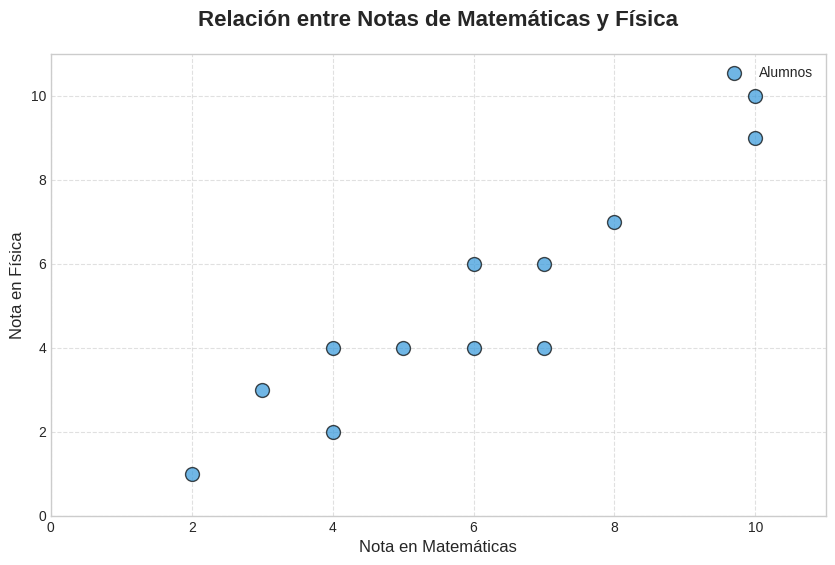

In [3]:
# 1. Configuramos el estilo y tamaño de la figura
plt.figure(figsize=(10, 6)) # Tamaño más grande y legible
plt.style.use('seaborn-v0_8-whitegrid') # Un estilo limpio con cuadrícula

# 2. Creamos la gráfica de dispersión con más detalle
plt.scatter(x, y, 
            color='#3498db',     # Color azul moderno
            s=100,               # Tamaño de los puntos
            alpha=0.7,           # Transparencia para ver puntos solapados
            edgecolors='black',  # Borde negro suave para cada punto
            linewidth=1,         # Grosor del borde
            label='Alumnos')     # Etiqueta para la leyenda

# 3. Personalizamos títulos y etiquetas de ejes
plt.title('Relación entre Notas de Matemáticas y Física', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nota en Matemáticas', fontsize=12)
plt.ylabel('Nota en Física', fontsize=12)

# 4. Ajustamos los límites de los ejes (notas de 0 a 10)
plt.xlim(0, 11)
plt.ylim(0, 11)

# 5. Añadimos detalles estéticos finales
plt.grid(True, linestyle='--', alpha=0.6) # Cuadrícula discontinua suave
plt.legend() # Mostramos la leyenda

# Mostramos la gráfica
plt.show()

Podemos observar a simple vista que existe una correlación entre la nota de física y la nota de matemáticas de cada estudiante. Cuanto mejor es la nota de matemáticas de un alumno, mejor es su nota de física. 

# Centro de gravedad de una distribución bidimensional.

Recuerda que la media de una variable X es $\bar{x} = \frac {\sum{x_i}} {n} $

Calculamos la media de la variable x y la media de la variable y. Esto nos dará un punto $(\bar{x},\bar{y})$ que será el centro de gravedad de nuestra distribución bidimensional.

In [5]:
media_x = np.mean(x)
media_y = np.mean(y)
print("El centro de gravedad es: (", media_x , "," , media_y, ")")

El centro de gravedad es: ( 6.0 , 5.0 )


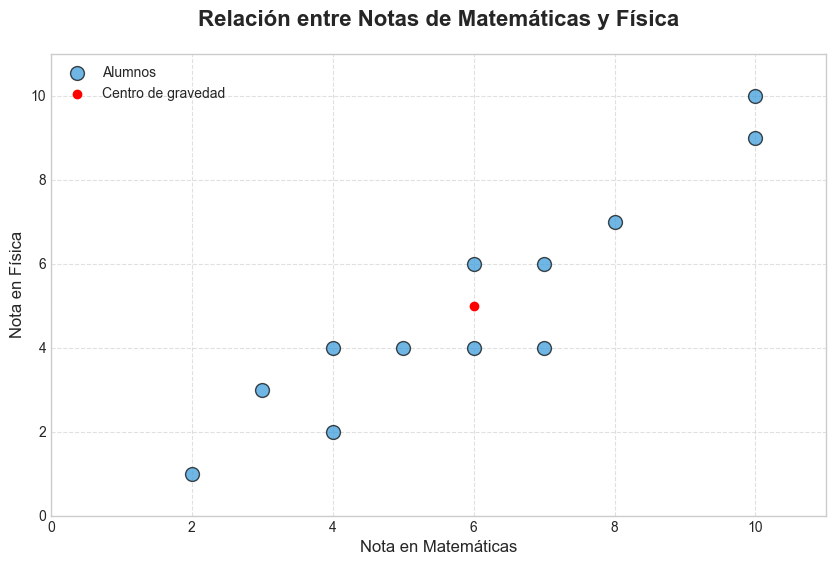

In [6]:
#Volvemos a mostrar la nube de puntos
plt.figure(figsize=(10, 6)) # Tamaño más grande y legible
plt.style.use('seaborn-v0_8-whitegrid') # Un estilo limpio con cuadrícula
plt.scatter(x, y, 
            color='#3498db',     # Color azul moderno
            s=100,               # Tamaño de los puntos
            alpha=0.7,           # Transparencia para ver puntos solapados
            edgecolors='black',  # Borde negro suave para cada punto
            linewidth=1,         # Grosor del borde
            label='Alumnos')     # Etiqueta para la leyenda
plt.title('Relación entre Notas de Matemáticas y Física', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nota en Matemáticas', fontsize=12)
plt.ylabel('Nota en Física', fontsize=12)
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True, linestyle='--', alpha=0.6) 

#Centro de gravedad de la distribución
plt.scatter(media_x, media_y, marker="o", color="red", label="Centro de gravedad")

plt.legend() 
plt.show()

# Covarianza

La covarianza es una medida de variación conjunta de dos variables respecto a sus medias. Sirve para determinar si existe cierto grado de dependencia entre ambas variables o no. 

La covarianza de dos variables, x e y, se calcula: $\sigma_{xy} = \frac {\sum{ ({x_i}-\bar{x})({y_i}-\bar{y}) }} {n} = \frac {\sum{ {x_i} {y_i} }} {n} - \bar{x} \bar{y} $

En numpy, disponemos de la función para calcular la covarianza np.cov(x, y)

La función devuelve una matriz de 4 valores, los cuales son, por posición:

[0,0] covarianza (x,x) | [0,1] covazianza (x,y)

[1,0] covarianza (y,x) | [1,1] covarianza (y,y)

In [7]:
# Calculamos la matriz de covarianzas. El parámetro bias=True sirve para indicar a la función que calcule la covarianza sobre N
matriz_cov = np.cov(x,y, bias=True)
print("Matriz de covarianzas")
print(matriz_cov)

print("Covarianza de xy es", matriz_cov[0,1])

Matriz de covarianzas
[[6.         5.91666667]
 [5.91666667 6.66666667]]
Covarianza de xy es 5.916666666666666


# Correlación 

El valor de correlación entre dos variables de una distribución bidimensiaonal viene dado por la expresión:

$r = \frac {\sigma_{xy}} {\sigma_x \sigma_y}$

El valor de r está comprendido entre -1 y 1:

+ Si la correlación es perfecta, esto es, sus puntos están alineados, entonces |r| = 1
+ Si la correlación es fuerte, |r| es próximo a 1.
+ Si la correlación es débil, |r| es próximo a 0.


In [8]:
# Calculamos la correlación entre las variables x e y.
# Primero calculamos la covarianza. Recuerda que la función nos devuelve la matriz, nos quedamos con la posición [0,1]
covXY=np.cov(x,y, bias=True)[0,1]

# Calculamos las desviaciones típicas de x e y.
desviacionX = np.std(x)
desviacionY = np.std(y)


# Calculamos la correlación 
r= covXY / (desviacionX * desviacionY)

# Redondeamos con 2 decimales
r = round (r, 2)
print("La correlación de las dos variables es: ",r)

La correlación de las dos variables es:  0.94


# Regresión Lineal Simple

Una rama de la inteligencia artificial y del aprendizaje automático trata de construir modelos basados en unos datos observados para realizar estimaciones. Una de estas técnicas es la Regresión Lineal.

Para nuestros datos de ejemplo (notas de matemáticas y física) podemos construir un modelo y hacer estimaciones para preguntarnos ¿cuál será la nota en física si el alumno tiene un 6,5 en matemáticas?

Podríamos trazar a ojo una recta que pase lo más cerca posible de todos los puntos. Vamos a trazar sobre nuestra nube de puntos una recta con origen en el punto (0,1) y fin en el punto (10,8) mediante la función plot()

Para pintar la recta, la función plot debe recibir dos puntos, origen y fin, de la siguiente manera:
plot( [origenX, finX], [origenY, finY], color línea)


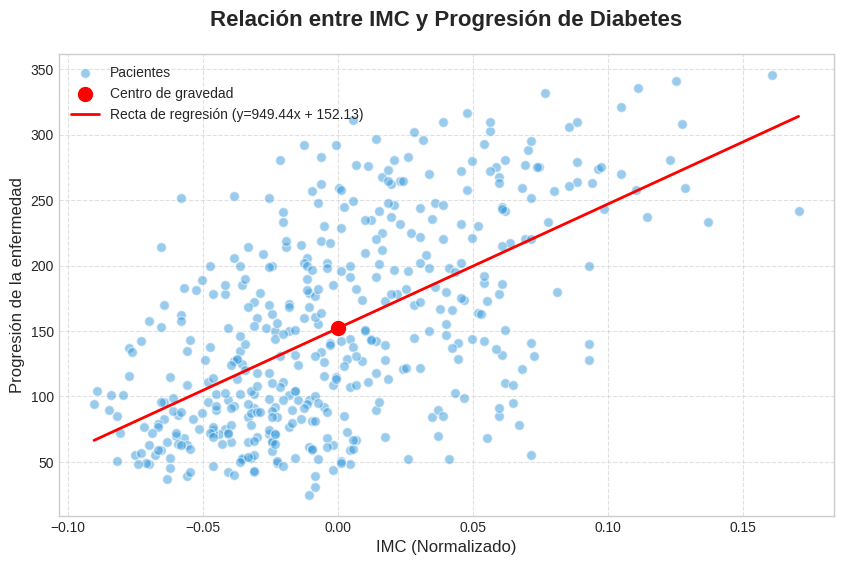

In [16]:
# 3. Calculamos la Recta de Regresión (la tendencia real)
# Esto sustituye a tus puntos manuales [0, 10] y [1, 8]
m, b = np.polyfit(x, y, 1) # Calcula la pendiente (m) y el punto de corte (b)
x_linea = np.array([x.min(), x.max()])
y_linea = m * x_linea + b

# 4. Graficamos
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Nube de puntos
plt.scatter(x, y, color='#3498db', s=50, alpha=0.5, edgecolors='white', label='Pacientes')

# Centro de gravedad
plt.scatter(media_x, media_y, marker="o", color="red", s=100, label="Centro de gravedad", zorder=5)

# Recta de regresión calculada
plt.plot(x_linea, y_linea, color="red", linewidth=2, label=f"Recta de regresión (y={m:.2f}x + {b:.2f})")

plt.title('Relación entre IMC y Progresión de Diabetes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('IMC (Normalizado)', fontsize=12)
plt.ylabel('Progresión de la enfermedad', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Recta de regresión: Método de mínimos cuadrados 

Observamos que la recta dibujada no pasa por el centro de gravedad y quedan muchos puntos por debajo y alejado de la recta. Gracias a la estadística y a las matemáticas, podemos encontrar la recta que mejor se ajusta a los datos. Esto, unido a la capacidad de computación de los ordenadores y a lenguajes como Python, nos permite realizar modelos sobre miles de observaciones que de otra forma sería imposible de analizar.  

Recordemos que la ecuación de la recta es $y = A + Bx$

De entre todas las rectas posibles ¿cómo podemos saber cuál es la que mejor representa los datos?  

Podemos calcular la distancia entre cada punto y una posible recta. Por ejemplo, el punto (10,9), donde el alumno tiene un 10 en matemáticas y un 9 en física. Sin embargo, la recta mostrada anteriormente prevee que para un 10 en la coordenada X, corresponde un 8 en la coordenada Y. Por lo tanto, la distancia, o el error, entre dichos puntos es d = 9-8 = 1.

Estos errores pueden ser positivos o negativos, dependiendo de si el punto está por debajo o por encima de la recta. Para eliminar el caracter del signo, se elevan todas las distancias al cuadrado y posteriormente se suman. Esto es lo que se denomina error del modelo: $error = \sum{d_i^2}$. 

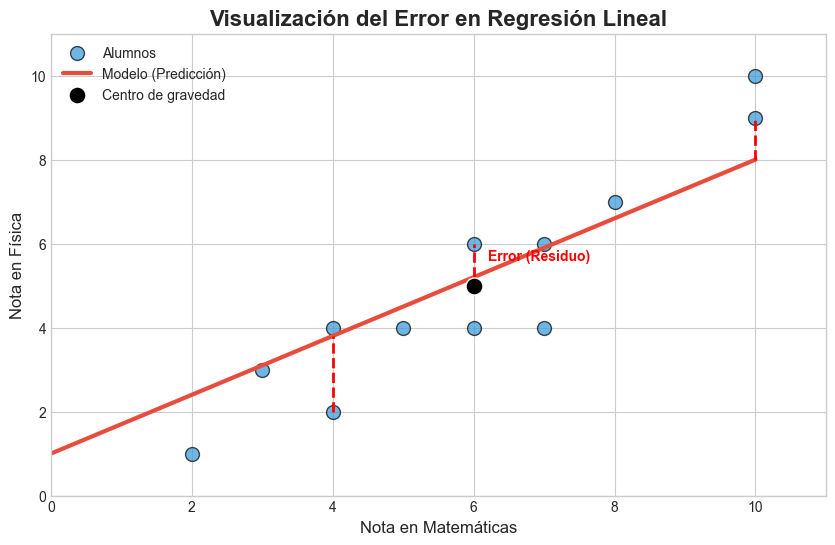

In [10]:
media_x, media_y = np.mean(x), np.mean(y)

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Nube de puntos
plt.scatter(x, y, color='#3498db', s=100, alpha=0.7, edgecolors='black', label='Alumnos')

# 2. Pintamos la recta (usando una función para poder calcular puntos intermedios)
# Según tus puntos [0,1] y [10,8], la pendiente es 0.7 y el origen 1 -> y = 0.7x + 1
def prediccion(val_x):
    return 0.7 * val_x + 1

x_recta = np.array([0, 10])
y_recta = prediccion(x_recta)
plt.plot(x_recta, y_recta, color="#e74c3c", linewidth=3, label="Modelo (Predicción)", zorder=1)

# 3. Dibujamos el ERROR (Residuos) para algunos puntos
# Elegimos por ejemplo el punto 2 (índice 2) y el punto 10 (índice 10)
puntos_a_marcar = [2, 6, 10] 

for i in puntos_a_marcar:
    x_punto = x[i]
    y_real = y[i]
    y_pred = prediccion(x_punto)
    
    # Dibujamos la línea vertical del error
    plt.vlines(x_punto, ymin=min(y_real, y_pred), ymax=max(y_real, y_pred), 
               color='red', linestyle='--', linewidth=2, zorder=2)
    
    # Añadimos una pequeña anotación de "Error" solo en uno para no saturar
    if i == 6:
        plt.text(x_punto + 0.2, (y_real + y_pred)/2, 'Error (Residuo)', color='red', fontweight='bold')

# 4. Centro de gravedad
plt.scatter(media_x, media_y, marker="o", color="black", s=150, edgecolors='white', label="Centro de gravedad", zorder=3)

# Configuración final
plt.title('Visualización del Error en Regresión Lineal', fontsize=16, fontweight='bold')
plt.xlabel('Nota en Matemáticas', fontsize=12)
plt.ylabel('Nota en Física', fontsize=12)
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.legend()
plt.show()

## Calcular la recta con MCO (mínimos cuadrados ordinarios)

De entre todas las rectas posibles, nos quedaremos con la recta donde el error sea mínimo. Esto es lo que se denomina Método de los mínimos cuadrados. $error = \sum{d_i^2}$. 

La tarea del algorimo consiste en buscar la __recta que minimiza la función de error__.

¿Pero debemos a calcular todas las rectas? Evidentemente no. 

La recta que hace mínimo el error, llamada recta de regresión de Y sobre X, es: 

$y = \bar{y} + \frac{\sigma_{xy}} {\sigma_x^2} (x-\bar{x})  $


Vamos a calcular los valores de y para:
+ x=2 (primer valor x)
+ x=6 (media de x) 
+ x=10 (último valor de x)

Una vez que tengamos esos valores, pintamos la nueva recta. 

In [11]:
#Covarianza xy
covxy = np.cov(x,y, bias=True)[0,1]
#Varianza de x
varx = np.var(x)
#media de x
meanx = np.mean(x)
#media de y
meany = np.mean(y)

#Calculamos y para x=2
y1 = meany + (covxy / varx)*(2-meanx)
print("Valor de y correspondiente a x=2: ", round(y1, 2))
#Calculamos y para x=6
y2 = meany + (covxy / varx)*(6-meanx)
print("Valor de y correspondiente a x=6: ", y2)
#Calculamos y para x=10
y3 = meany + (covxy / varx)*(10-meanx)
print("Valor de y correspondiente a x=10: ", round(y3, 2))


Valor de y correspondiente a x=2:  1.06
Valor de y correspondiente a x=6:  5.0
Valor de y correspondiente a x=10:  8.94


Podemos observar que el valor calculado para y siendo x=6 (media de x), coincide con la media de y, dando así la recta su paso por el centro de gravedad.

Ahora podemos pintar la recta entre los puntos (2, 1.06) (10, 8.94)

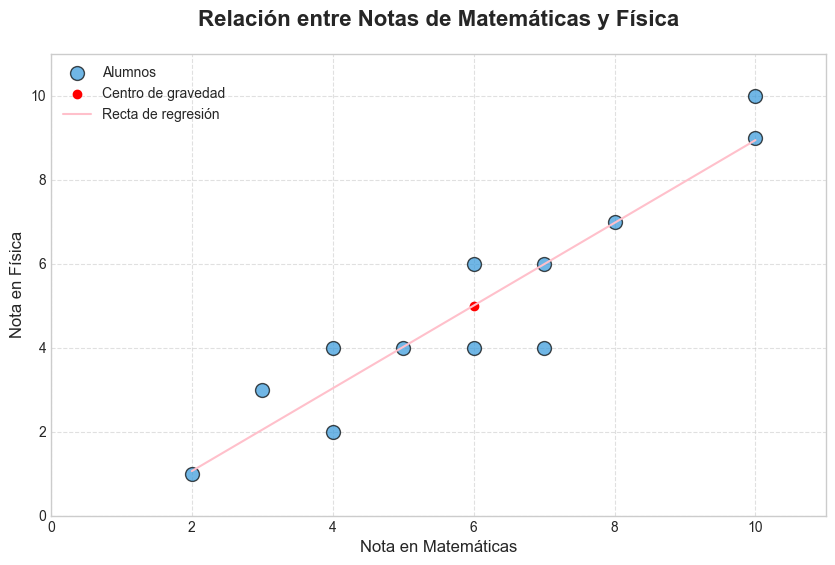

In [12]:
#Volvemos a mostrar la nube de puntos
plt.figure(figsize=(10, 6)) # Tamaño más grande y legible
plt.style.use('seaborn-v0_8-whitegrid') # Un estilo limpio con cuadrícula
plt.scatter(x, y, 
            color='#3498db',     # Color azul moderno
            s=100,               # Tamaño de los puntos
            alpha=0.7,           # Transparencia para ver puntos solapados
            edgecolors='black',  # Borde negro suave para cada punto
            linewidth=1,         # Grosor del borde
            label='Alumnos')     # Etiqueta para la leyenda
plt.title('Relación entre Notas de Matemáticas y Física', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nota en Matemáticas', fontsize=12)
plt.ylabel('Nota en Física', fontsize=12)
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True, linestyle='--', alpha=0.6) 

#Centro de gravedad de la distribución
plt.scatter(media_x, media_y, marker="o", color="red", label="Centro de gravedad")

# Pintamos la recta de regresión
plt.plot([2,10],[1.06,8.94], color="pink", label="Recta de regresión")
plt.legend() 
plt.show()

# Regresión Lineal haciendo uso de NumPy

Disponemos de funciones en la biblioteca para hacer lo mismo de forma más directa.

Recordemos que la ecuación de la recta es $y = A + Bx$

A = Término independiente

B = Pendiente

La función de la biblioteca numpy.polyfit nos va a calcular tales valores haciendo mínimo el error MCO.

Pendiente:  0.986111111111111
Término independiente:  -0.9166666666666643
Ecuación de la recta:  
0.9861 x - 0.9167
Valores de y correspondientes a x=2, x=10:  [1.05555556 8.94444444]


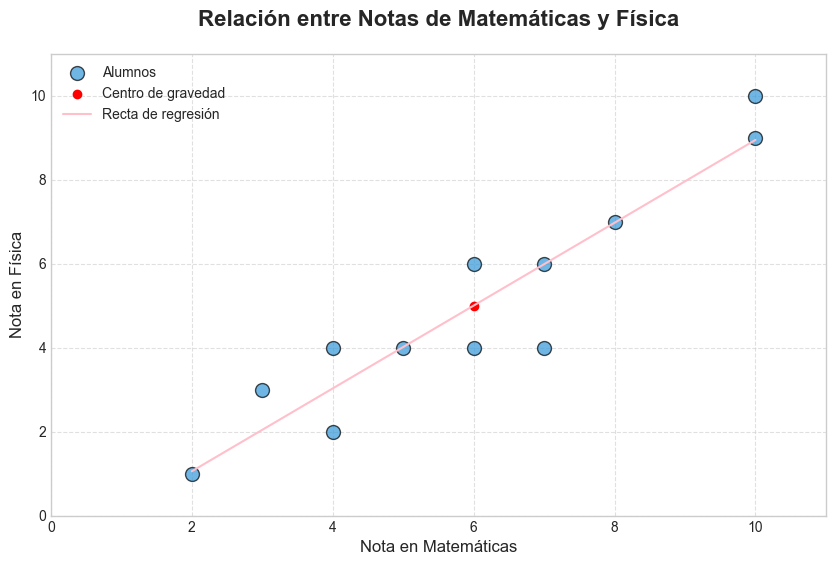

In [13]:
# Calculamos la pendiente y término independiente con la función polyfit. Pasamos como parámetros los datos. 
linear_model = np.polyfit(x, y, 1)

# La función polyfit nos devuelve un vector, en la posición 0 almacena la pendiente, en la posición 1 el término independiente
print("Pendiente: ", linear_model[0])
print("Término independiente: ", linear_model[1])

# Establecemos el modelo de regresión lineal con los valores calculados.
linear_model_fn = np.poly1d(linear_model)
print("Ecuación de la recta:", linear_model_fn)

#Las coordenadas de x en origen y fin de la recta que vamos a pintar son x=2, x=10, correspondientes a primer y último valor
valores_x = [2, 10]

#Gracias al modelo calculado, obtenemos los puntos de y correspondientes para valores x=2, x=10
valores_y = linear_model_fn(valores_x)
print("Valores de y correspondientes a x=2, x=10: ", valores_y)


#Volvemos a mostrar la nube de puntos
plt.figure(figsize=(10, 6)) # Tamaño más grande y legible
plt.style.use('seaborn-v0_8-whitegrid') # Un estilo limpio con cuadrícula
plt.scatter(x, y, 
            color='#3498db',     # Color azul moderno
            s=100,               # Tamaño de los puntos
            alpha=0.7,           # Transparencia para ver puntos solapados
            edgecolors='black',  # Borde negro suave para cada punto
            linewidth=1,         # Grosor del borde
            label='Alumnos')     # Etiqueta para la leyenda
plt.title('Relación entre Notas de Matemáticas y Física', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nota en Matemáticas', fontsize=12)
plt.ylabel('Nota en Física', fontsize=12)
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True, linestyle='--', alpha=0.6) 

#Centro de gravedad de la distribución
plt.scatter(media_x, media_y, marker="o", color="red", label="Centro de gravedad")

# Pintamos la recta de regresión
plt.plot(valores_x, valores_y, color="pink", label="Recta de regresión")
plt.legend() 
plt.show()

# Estimaciones

Si un alumno obiene un 6.5 en matemáticas, ¿qué nota en física podemos predecir con nuestro modelo?

Podemos usar la ecuación de la recta haciendo uso del término independiente y pendiente calculados anteriormente: $y = -0.9167 + 0.9861 x$ 

Para $x=6.5$ obtenemos que $y=5.49$ 

O hacemos uso del modelo creado anteriormente.

In [14]:
nota_mates = 6.5
nota_fisica = linear_model_fn(nota_mates)
nota_fisica = round(nota_fisica, 2)
print("Si tengo un 6,5 en matemáticas, la previsión es que saque en física", nota_fisica)

Si tengo un 6,5 en matemáticas, la previsión es que saque en física 5.49


# Para practicar y evaluar lo aprendido

Visualiza la presentación (ejecuta la celda si no está visible) y responde al Quiz ayudandote de la programación en Python

In [15]:
from IPython.display import IFrame
IFrame('https://view.genially.com/69aeab4b8e7065e2ca05ad7f', width=900, height=500)

In [11]:
# Importación de datos
from sklearn.datasets import load_diabetes

# Cargamos el dataset
datos, target = load_diabetes(return_X_y=True)

# X = IMC (Body Mass Index), y = Progresión de la enfermedad
x = datos[:, 2]
y = target

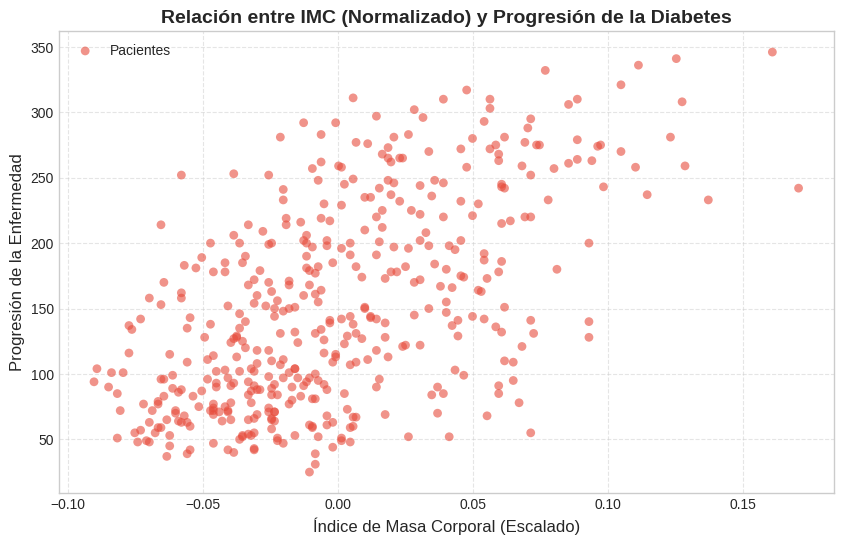

In [12]:
# 1. Configuración de estilo
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Creación del gráfico de dispersión
plt.scatter(x, y, 
            color='#e74c3c',     # Rojo coral para contrastar
            s=40,                # Tamaño reducido para mejor visualización de densidad
            alpha=0.6,           # Transparencia para ver solapamiento
            edgecolors='none',   # Sin bordes para evitar ruido visual
            label='Pacientes')

# 3. Personalización de etiquetas (Contexto Real: Diabetes)
plt.title('Relación entre IMC (Normalizado) y Progresión de la Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Índice de Masa Corporal (Escalado)', fontsize=12)
plt.ylabel('Progresión de la Enfermedad', fontsize=12)

# 4. Detalles finales
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Mostrar resultado
plt.show()

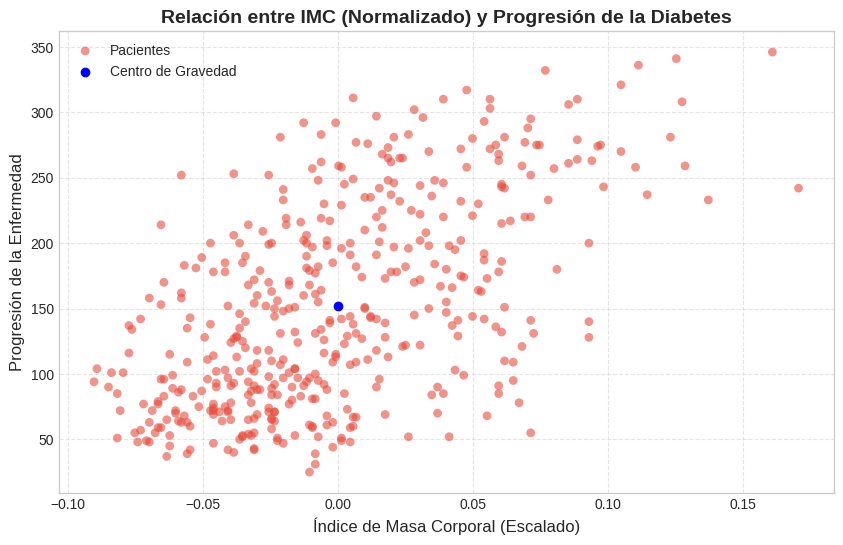

In [13]:
#CENTRO DE GRAVEDAD
media_x = np.mean(x)
media_y = np.mean(y)


plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Creación del gráfico de dispersión
plt.scatter(x, y, 
            color='#e74c3c',     # Rojo coral para contrastar
            s=40,                # Tamaño reducido para mejor visualización de densidad
            alpha=0.6,           # Transparencia para ver solapamiento
            edgecolors='none',   # Sin bordes para evitar ruido visual
            label='Pacientes')

# 3. Personalización de etiquetas (Contexto Real: Diabetes)
plt.title('Relación entre IMC (Normalizado) y Progresión de la Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Índice de Masa Corporal (Escalado)', fontsize=12)
plt.ylabel('Progresión de la Enfermedad', fontsize=12)

# 4. Detalles finales
plt.grid(True, linestyle='--', alpha=0.5)

#CENTRO DE GRAVEDAD
plt.scatter(media_x, media_y, marker="o", color="blue", label="Centro de Gravedad")


plt.legend()

# Mostrar resultado
plt.show()

In [14]:
#COVARIANZA
matriz_cov = np.cov(x,y, bias=True)
print("Matriz de covarianzas")
print(matriz_cov)

print("Covarianza de xy es", matriz_cov[0,1])

Matriz de covarianzas
[[2.26244344e-03 2.14804358e+00]
 [2.14804358e+00 5.92988490e+03]]
Covarianza de xy es 2.1480435755294978


In [17]:
#CORRELACION
# Calculamos la correlación entre las variables x e y.
# Primero calculamos la covarianza. Recuerda que la función nos devuelve la matriz, nos quedamos con la posición [0,1]
covXY=np.cov(x,y, bias=True)[0,1]

# Calculamos las desviaciones típicas de x e y.
desviacionX = np.std(x)
desviacionY = np.std(y)


# Calculamos la correlación 
r= covXY / (desviacionX * desviacionY)

# Redondeamos con 2 decimales
r = round (r, 2)
print("La correlación de las dos variables es: ",r)

La correlación de las dos variables es:  0.59


## Pinta la recta de regresión sobre la nube de puntos y el centro de gravedad

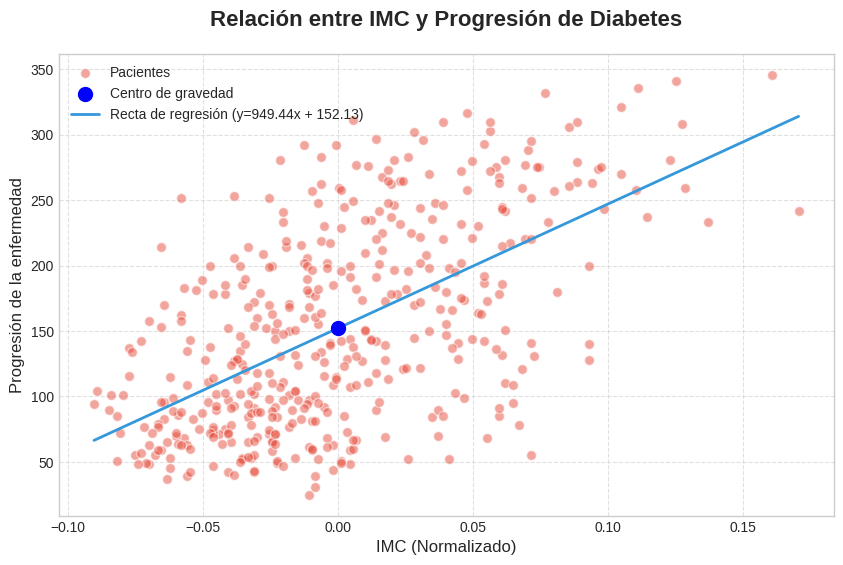

In [19]:
# 3. Calculamos la Recta de Regresión (la tendencia real)
# Esto sustituye a tus puntos manuales [0, 10] y [1, 8]
m, b = np.polyfit(x, y, 1) # Calcula la pendiente (m) y el punto de corte (b)
x_linea = np.array([x.min(), x.max()])
y_linea = m * x_linea + b

# 4. Graficamos
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Nube de puntos
plt.scatter(x, y, color='#e74c3c', s=50, alpha=0.5, edgecolors='white', label='Pacientes')

# Centro de gravedad
plt.scatter(media_x, media_y, marker="o", color="blue", s=100, label="Centro de gravedad", zorder=5)

# Recta de regresión calculada
plt.plot(x_linea, y_linea, color="#3498db", linewidth=2, label=f"Recta de regresión (y={m:.2f}x + {b:.2f})")

plt.title('Relación entre IMC y Progresión de Diabetes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('IMC (Normalizado)', fontsize=12)
plt.ylabel('Progresión de la enfermedad', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Realiza un diagrama de tartas para ver la proporción de hombres y mujeres

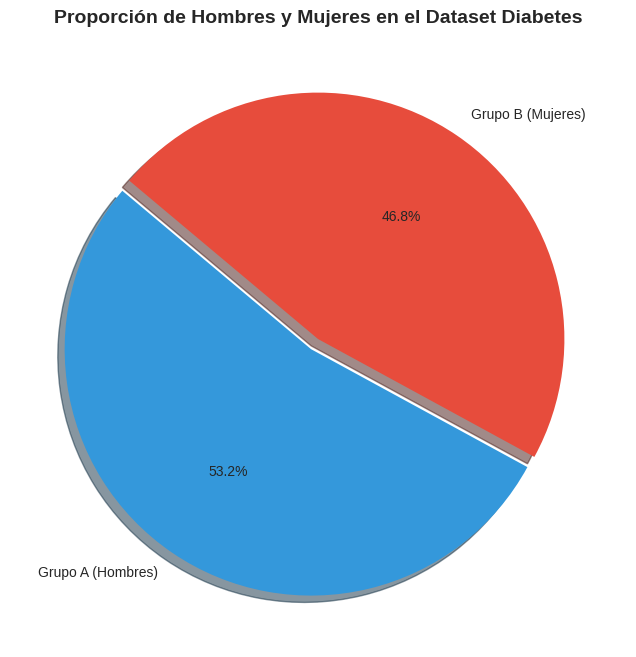

In [24]:
# 1. Extraemos la columna del sexo (índice 1)
sexo_data = datos[:, 1]

# 2. Contamos cuántos valores únicos hay
# Como están normalizados, no son 0 y 1 exactos, pero hay dos grupos
valores, cuentas = np.unique(sexo_data, return_counts=True)

# 3. Definimos etiquetas y colores
etiquetas = ['Grupo A (Hombres)', 'Grupo B (Mujeres)']
colores = ['#3498db', '#e74c3c'] # Azul y Rojo suave

# 4. Creamos el gráfico de tartas
plt.figure(figsize=(8, 8))
plt.pie(cuentas, 
        labels=etiquetas, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colores,
        explode=(0.05, 0), # Separamos un poco la primera porción
        shadow=True)

plt.title('Proporción de Hombres y Mujeres en el Dataset Diabetes', fontsize=14, fontweight='bold')
plt.show()

## Mostrar en un diagrama de barras la cantidad de pacientes por incremento de IMC de los grupos realizados 

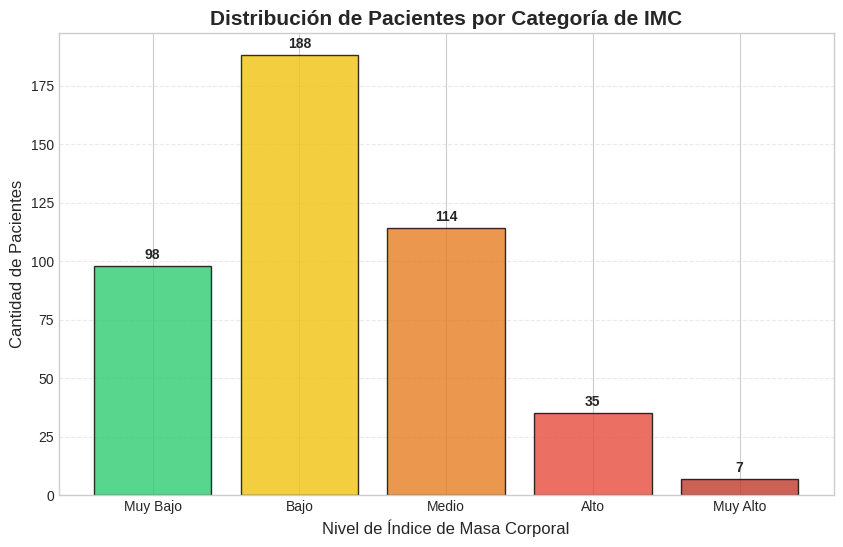

In [25]:
# 1. Definimos el número de grupos y las etiquetas solicitadas
n_grupos = 5
etiquetas = ['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto']

# 2. Agrupamos los datos del IMC (x) en 5 bloques, similar a pandas.cut
frecuencias, bordes = np.histogram(x, bins=n_grupos)

# 3. Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
# Usamos un degradado de color (de verde a rojo) para indicar el aumento de IMC
colores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']

barras = plt.bar(etiquetas, frecuencias, color=colores, edgecolor='black', alpha=0.8)

# Añadimos las etiquetas de datos sobre las barras
plt.bar_label(barras, padding=3, fontweight='bold')

# 4. Estética del gráfico
plt.title('Distribución de Pacientes por Categoría de IMC', fontsize=15, fontweight='bold')
plt.xlabel('Nivel de Índice de Masa Corporal', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()